# Анализ семантического сходства отчетов

Конфигурация: указать нужные пути к папкам

In [7]:
# путь к папке с JSON файлами выборки (обработанными отчетами 10-K)
DATA_DIR = "/Users/dariazvereva/Documents/kursovaya/ВЫБОРКА"

# путь для сохранения результатов
OUTPUT_CSV = "/Users/dariazvereva/Documents/kursovaya/косинусная близость отчетов.csv"

# путь к файлу с результатами подстчета косинусной близости
DATA_CSV = "/content/drive/MyDrive/анализ отчетов/косинусная близость отчетов.csv"

Подсчет косинусной близости для разделов 1 и 7, 1А и 7

In [10]:
import os
import json
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

Mounted at /content/drive


In [ ]:
documents = []

for filename in os.listdir(DATA_DIR):

    if filename.endswith(".json"):

        filepath = os.path.join(DATA_DIR, filename)

        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        documents.append({
            "company": (
                data.get("company")
                if data.get("company")
                else filename.split("-")[0]
            ),
            "year": data.get("fiscal_year"),

            "section_1": data.get("section_item_1", ""),
            "section_1A": data.get("section_item_1a", ""),
            "section_7": data.get("section_item_7", ""),
            "section_7A": data.get("section_item_7a", "")
        })

df = pd.DataFrame(documents)

model = SentenceTransformer("all-MiniLM-L6-v2")

def prepare_text(text):
    if not isinstance(text, str):
        return ""

    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = " ".join(text.split())

    if len(text.split()) < 50:
        return ""

    return text


def split_into_chunks(text, chunk_size=500):
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = words[i:i + chunk_size]
        chunks.append(" ".join(chunk))

    return chunks


def get_document_embedding(text, model):
    chunks = split_into_chunks(text)

    if len(chunks) == 0:
        return None

    chunk_embeddings = model.encode(
        chunks,
        show_progress_bar=False
    )

    document_embedding = np.mean(chunk_embeddings, axis=0)
    return document_embedding


similarities = []

for idx, row in df.iterrows():
    text_1 = prepare_text(row["section_1"])
    text_1A = prepare_text(row["section_1A"])
    text_7 = prepare_text(row["section_7"])

    if len(text_7) < 100:
        continue

    try:

        emb_1 = get_document_embedding(text_1, model) if len(text_1) > 100 else None
        emb_1A = get_document_embedding(text_1A, model) if len(text_1A) > 100 else None
        emb_7 = get_document_embedding(text_7, model)



        sim_1_7 = None
        if emb_1 is not None:
            sim_1_7 = cosine_similarity([emb_1],[emb_7])[0][0]

        sim_1A_7 = None
        if emb_1A is not None:
            sim_1A_7 = cosine_similarity([emb_1A],[emb_7])[0][0]

        similarities.append({
            "company": row["company"],
            "year": row["year"],
            "similarity_1_7": sim_1_7,
            "similarity_1A_7": sim_1A_7,
        })


    except Exception as e:
        print(f"\nError in {row['company']} {row['year']}: {e}")
        continue

results_df = pd.DataFrame(similarities)

results_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

Статистика по косинусной близости

In [11]:
import pandas as pd

df = pd.read_csv(DATA_CSV, sep=';')

df.head()

df[['similarity_1_7', 'similarity_1A_7']].describe()

,similarity_1_7,similarity_1A_7
count,99.000000,94.000000
mean,0.530914,0.516954
std,0.196101,0.172679
min,0.152610,0.086113
25%,0.357018,0.406882
50%,0.550194,0.525071
75%,0.701687,0.597708
max,0.878514,0.949950


Расчет показателя gap

In [12]:
df['gap'] = df['similarity_1_7'] - df['similarity_1A_7']

df[['gap']].describe()

,gap
count,94.000000
mean,0.008220
std,0.238479
min,-0.498255
25%,-0.128838
50%,-0.008256
75%,0.151511
max,0.594094


Визуализация распределения similarity-значений

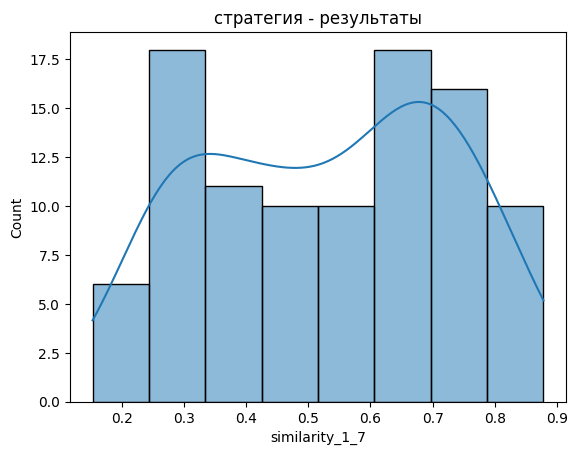

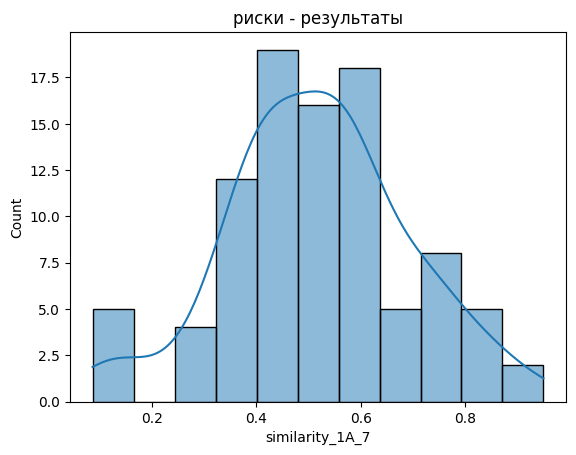

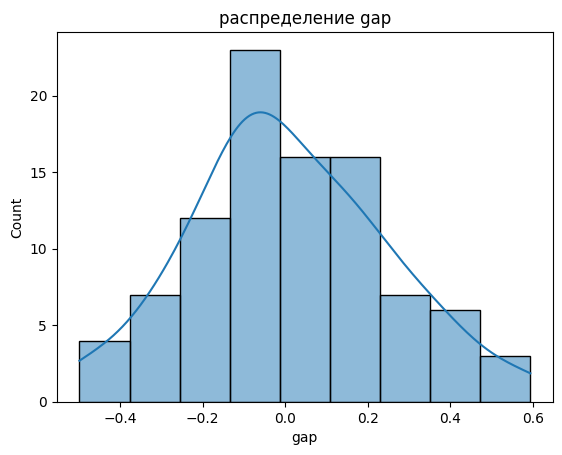

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['similarity_1_7'], kde=True)
plt.title("стратегия - результаты")
plt.show()

sns.histplot(df['similarity_1A_7'], kde=True)
plt.title("риски - результаты")
plt.show()

sns.histplot(df['gap'], kde=True)
plt.title("распределение gap")
plt.show()

Кластеризация + визуализация

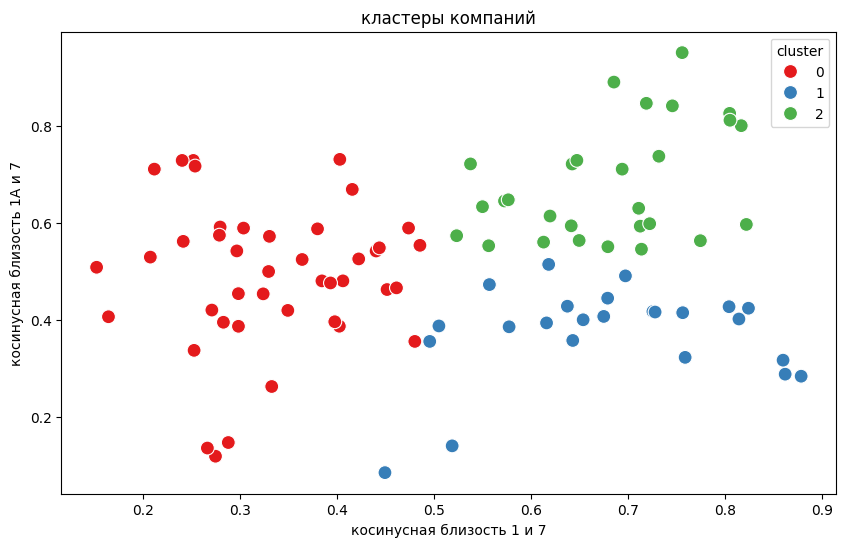

        similarity_1_7                                                    \
                 count      mean       std       min       25%       50%   
cluster                                                                    
0                 42.0  0.333326  0.087932  0.152610  0.272318  0.327037   
1                 24.0  0.680773  0.124527  0.449720  0.606552  0.677144   
2                 28.0  0.679572  0.088294  0.523584  0.618128  0.689863   

                            similarity_1A_7                                \
              75%       max           count      mean       std       min   
cluster                                                                     
0        0.403095  0.485762            42.0  0.489771  0.148985  0.119860   
1        0.770300  0.878514            24.0  0.374366  0.098682  0.086113   
2        0.735415  0.822065            28.0  0.679946  0.118041  0.545690   

                                                 
              25%       50%   

In [14]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

X_clean = df[['similarity_1_7', 'similarity_1A_7']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_clean)

df_clustered = X_clean.copy()
df_clustered['cluster'] = clusters
df_clustered['company'] = df.loc[X_clean.index, 'company']
df_clustered['year'] = df.loc[X_clean.index, 'year']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustered,
    x='similarity_1_7',
    y='similarity_1A_7',
    hue='cluster',
    palette='Set1',
    s=100
)
plt.title("кластеры компаний")
plt.xlabel("косинусная близость 1 и 7")
plt.ylabel("косинусная близость 1А и 7")
plt.show()

print(df_clustered.groupby('cluster')[['similarity_1_7', 'similarity_1A_7']].describe())



Средняя дискурсивная ориентация компаний

In [ ]:
df = df.sort_values(['company', 'year'])

df['delta_1_7'] = df.groupby('company')['similarity_1_7'].diff()
df['delta_1A_7'] = df.groupby('company')['similarity_1A_7'].diff()
df[['delta_1_7', 'delta_1A_7']].mean()

,0
delta_1_7,0.001721
delta_1A_7,-0.002552


Ранжирование компаний по согласованности корпоративного дискурса

In [ ]:
df.groupby('company')['gap'].mean().sort_values()

,gap
company,
unh,-0.487235
psx,-0.294253
hd,-0.247444
adm,-0.239865
meta,-0.214949
vlo,-0.207216
fdx,-0.194486
elv,-0.164151
tsla,-0.152041


Визуализация по компаниям


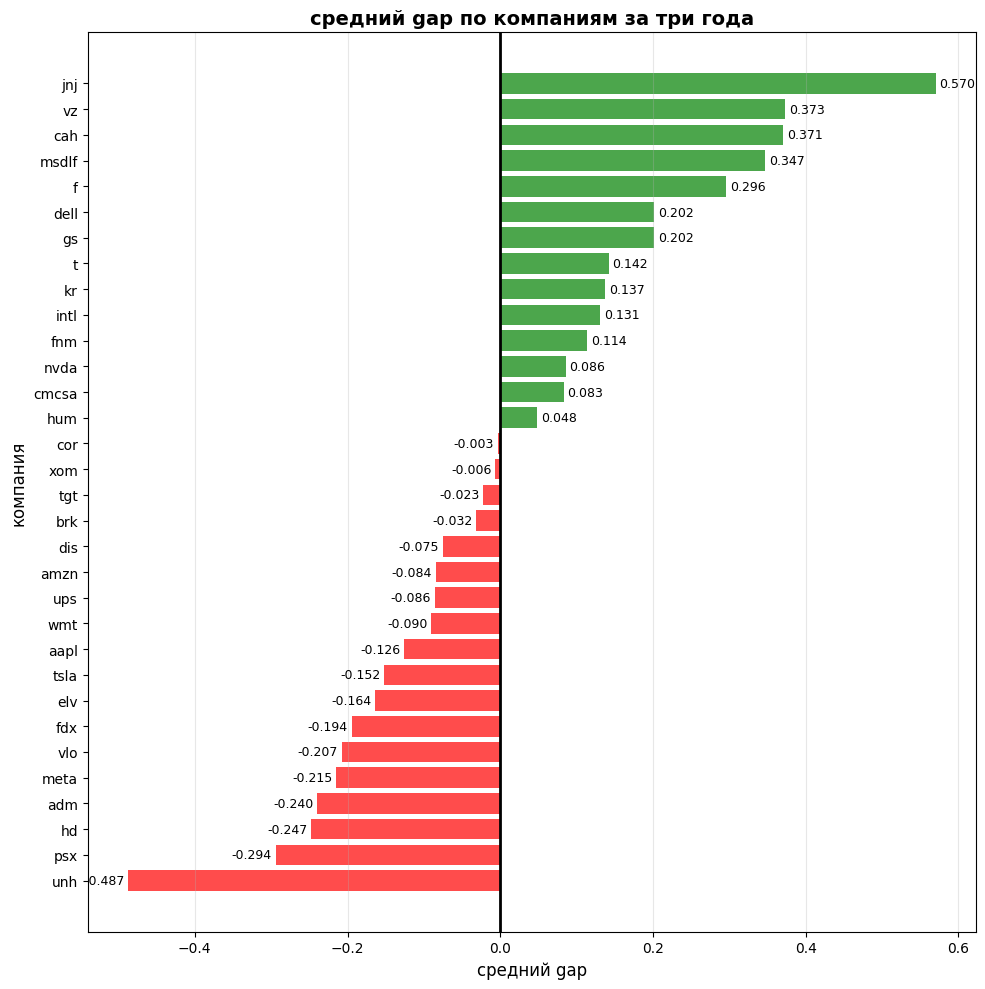

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df_avg = df.groupby('company')['gap'].mean().dropna().reset_index()
df_avg = df_avg.sort_values('gap')

colors = ['red' if x < 0 else 'green' for x in df_avg['gap']]

plt.figure(figsize=(10, 10))
plt.barh(df_avg['company'], df_avg['gap'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linewidth=2)
plt.xlabel('средний gap', fontsize=12)
plt.ylabel('компания', fontsize=12)
plt.title('cредний gap по компаниям за три года', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, (val, company) in enumerate(zip(df_avg['gap'], df_avg['company'])):
    x_pos = val + 0.005 if val > 0 else val - 0.005
    ha = 'left' if val > 0 else 'right'
    plt.text(x_pos, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()